# Introduction to DL

## Perceptron

In [2]:
import numpy as np
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
list(iris)

X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 0) # Setosa

per_clf = Perceptron()
per_clf.fit(X, y)

X_new = [[1.5, 0.5], [1.4, 1.9]]
print(per_clf.predict(X_new))

[ True False]


## Regression MLP

In [3]:
from sklearn.datasets import fetch_california_housing
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

housing = fetch_california_housing(as_frame=True)
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full)

mlp_reg = MLPRegressor(hidden_layer_sizes=[50, 50, 50], max_iter=500)
pipeline = make_pipeline(StandardScaler(), mlp_reg)
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_valid)

print(f"RMSE: {root_mean_squared_error(y_valid, y_pred)}")

RMSE: 0.5306308891965589


## Classification MLP

In [4]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

iris = load_iris(as_frame=True)
X, y = iris.data, iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5)

mlp_clf = MLPClassifier(hidden_layer_sizes=[10], max_iter=500)
mlp_clf.fit(X_train, y_train)

y_pred = mlp_clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")

Accuracy: 0.96


c:\Users\Yehor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


# MLPs via Keras

In [5]:
import keras
import tensorflow as tf
import numpy as np

fashion_mnist = keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test_full, y_test_full) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000] # cutting of 5000 indexes from end
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:] # taking cutted of 5000 indexes from end

print(X_train.shape)
print(X_train.dtype)

X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

print(f"Labels: {[(i, label) for i, label in zip(range(len(class_names)), class_names)]}")

c:\Users\Yehor\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\api_core\__init__.py:20: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution


(55000, 28, 28)
uint8
Labels: [(0, 'T-shirt/top'), (1, 'Trouser'), (2, 'Pullover'), (3, 'Dress'), (4, 'Coat'), (5, 'Sandal'), (6, 'Shirt'), (7, 'Sneaker'), (8, 'Bag'), (9, 'Ankle boot')]


In [6]:
keras.backend.clear_session()

model = keras.Sequential()
model.add(keras.layers.Input(shape=(28, 28)))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(300, activation="relu"))
model.add(keras.layers.Dense(100, activation="relu"))

# --- or ---

model = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),
    keras.layers.Flatten(), # converts 28x28 matrix to a flattene array-vector of shape 7845
    keras.layers.Dense(300, activation="relu"),
    keras.layers.Dense(100, activation="relu"),
    keras.layers.Dense(10, activation="softmax"),
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
print(model.get_layer("dense_2") is model.layers[1])

dense_layer_2 = model.get_layer("dense_3")
print(f"Layer parameters (weights): {dense_layer_2.get_weights()[0]}") # get_weights() -> (weights, biases)
print(f"Weights shape: {dense_layer_2.get_weights()[0].shape}")

True
Layer parameters (weights): [[-0.10968529  0.05991083 -0.00998498 ... -0.07963365 -0.07486135
  -0.11736775]
 [-0.07461207 -0.06695706 -0.00082505 ... -0.12129024 -0.10731874
   0.0256486 ]
 [ 0.05008347 -0.02026832  0.05439801 ... -0.10539833  0.09281106
   0.05682074]
 ...
 [ 0.08685843  0.10987636 -0.07764336 ...  0.08789491 -0.05722429
   0.01247374]
 [-0.05202172 -0.0695077  -0.00017403 ...  0.0581638   0.03719033
   0.05238631]
 [ 0.11539429  0.05940922 -0.0654425  ... -0.0304042   0.08530357
  -0.11368435]]
Weights shape: (300, 100)


In [8]:
model.compile(loss="sparse_categorical_crossentropy", optimizer="sgd", metrics=["accuracy"])
fashion_mnist = model = model

In [9]:
history = model.fit(X_train, y_train, epochs=30, validation_split=0.2)

Epoch 1/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7557 - loss: 0.7432 - val_accuracy: 0.8182 - val_loss: 0.5384
Epoch 2/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 1s 935us/step - accuracy: 0.8261 - loss: 0.5048 - val_accuracy: 0.8233 - val_loss: 0.4990
Epoch 3/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 1s 969us/step - accuracy: 0.8408 - loss: 0.4569 - val_accuracy: 0.8316 - val_loss: 0.4811
Epoch 4/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 1s 942us/step - accuracy: 0.8512 - loss: 0.4285 - val_accuracy: 0.8469 - val_loss: 0.4466
Epoch 5/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 1s 952us/step - accuracy: 0.8576 - loss: 0.4088 - val_accuracy: 0.8357 - val_loss: 0.4528
Epoch 6/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 1s 957us/step - accuracy: 0.8622 - loss: 0.3921 - val_accuracy: 0.8612 - val_loss: 0.4049
Epoch 7/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 1s 959us/step - accuracy: 0.8672 - loss: 0.3786 - val_accuracy: 0.8594 - val_loss: 0.4013
Epoch 8/30
1375/1375 ━━━━━━━━━━━━━━━━━━━━ 1s 950us/step - accuracy: 0.8720 - l

['accuracy', 'loss', 'val_accuracy', 'val_loss']


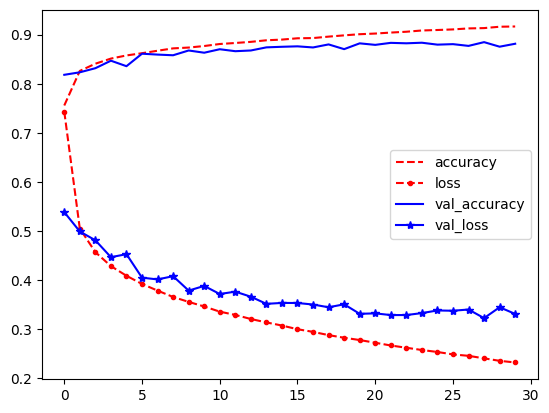

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

print(list(history.history))
pd.DataFrame(history.history).plot(
    style=["r--", "r--.", "b-", "b-*"]
)
plt.show()

In [11]:
model.evaluate(X_valid, y_valid)

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 768us/step - accuracy: 0.8836 - loss: 0.3291


[0.32906028628349304, 0.8835999965667725]

In [12]:
X_new = X_valid[:3]
y_pred = np.argmax(model.predict(X_new), axis=-1)

print(f"Predictions: {np.array(class_names)[y_pred]}")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predictions: ['Shirt' 'Bag' 'T-shirt/top']


# Wide & Deep DNN (Functional API)

In [13]:
normalization_layer = keras.layers.Normalization() # same as sklearn's StandarScaler
hidden_layer_1 = keras.layers.Dense(30, activation="relu")
hidden_layer_2 = keras.layers.Dense(30, activation="relu")
concatenate_layer = keras.layers.Concatenate()
output_layer = keras.layers.Dense(1)

input_ = keras.layers.Input(shape=X_train.shape[1:]) # skip dataset size in shape [!55000!, 28, 28]
normalized = normalization_layer(input_)
hidden_1 = hidden_layer_1(normalized)
hidden_2 = hidden_layer_2(hidden_1)
concat = concatenate_layer([hidden_2, normalized])
output = output_layer(concat)

model = keras.Model(inputs=[input_], outputs=[output])

# Subclass API

In [43]:
class WideAndDeepModel(keras.Model):
    def __init__(self, units: int = 30, activation="relu", **kwargs):
        super().__init__(**kwargs)

        self.norm_layer_wide = keras.layers.Normalization()
        self.nowrm_layer_deep = keras.layers.Normalization()
        self.hidden1 = keras.layers.Dense(units=units, activation=activation)
        self.hidden1 = keras.layers.Dense(units=units, activation=activation)
        self.main_output = keras.layers.Dense(1)
        self.aux_output = keras.layers.Dense(12)

    def call(self, inputs):
        input_wide, input_deep = inputs
        norm_wide = self.norm_layer_wide(input_wide)
        norm_deep = self.norm_layer_deep(input_deep)

        hidden1 = self.hidden1(norm_deep)
        hidden2 = self.hidden2(hidden1)

        concatenate = keras.layers.concatenate([hidden2, norm_wide])

        main_output = self.main_output(concatenate)
        aux_output = self.aux_output(hidden2)

        return main_output, aux_output

wide_deep_model = WideAndDeepModel(30, activation="relu", name="wide_and_deep_model")


# Export

In [41]:
import shutil
import os

shutil.rmtree("./export-example", ignore_errors=True) # forcefuly remove not empty directory
os.mkdir("./export-example")

fashion_mnist.save("./export-example/fashion_mnist_model.keras") # zip file
fashion_mnist.save_weights("./export-example/fasion_mnist_model.weights.h5") # .weights.h5 extension

In [42]:
saved_model = keras.models.load_model("./export-example/fashion_mnist_model.keras")
saved_model.load_weights("./export-example/fasion_mnist_model.weights.h5") # only for example, save() saved the model including learned parameters

## Custom Objects Export

In [46]:
wide_deep_model.save("./export-example/wide_and_deep.keras")
saved_wide_deep = keras.models.load_model("./export-example/wide_and_deep.keras", custom_objects={"WideAndDeepModel": WideAndDeepModel}) # include custom objects that model is using e.g. external: functions, classes, variables

c:\Users\Yehor\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_api.py:108: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)


# Callbacks

In [52]:
shutil.rmtree("./example", ignore_errors=True)

checkpoint_cb = keras.callbacks.ModelCheckpoint("example/my-checkpoints.weights.h5", save_weights_only=True, save_best_only=True) # save_weights_only=False -> path ends with .keras
early_stopping_cb = keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)

class CustomCallback(keras.callbacks.Callback):
    def __init__(self):
        super().__init__()

    def set_model(self, model):
        super().set_model(model)

    def set_params(self, params):
        super().set_params(params)

    def on_train_begin(self, logs=None):
        pass

    def on_train_end(self, logs=None):
        pass

    def on_epoch_begin(self, epoch, logs=None):
        pass

    def on_epoch_end(self, epoch, logs=None):
        pass

    def on_train_batch_begin(self, batch, logs=None):
        pass

    def on_train_batch_end(self, batch, logs=None):
        pass

    def on_test_begin(self, logs=None):
        pass

    def on_test_end(self, logs=None):
        pass

    def on_test_batch_begin(self, batch, logs=None):
        pass

    def on_test_batch_end(self, batch, logs=None):
        pass

    def on_predict_begin(self, logs=None):
        pass

    def on_predict_end(self, logs=None):
        pass

    def on_predict_batch_begin(self, batch, logs=None):
        pass

    def on_predict_batch_end(self, batch, logs=None):
        pass

# history = fashion_mnist.fit([...], callbacks=[checkpoint_cb])


# Tensorboard